<a href="https://colab.research.google.com/github/uday367/deep-learning/blob/main/alexnet_with_mnist_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 161s 85ms/step - accuracy: 0.9584 - loss: 0.1366 - val_accuracy: 0.9880 - val_loss: 0.0396
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 203s 85ms/step - accuracy: 0.9851 - loss: 0.0493 - val_accuracy: 0.9907 - val_loss: 0.0261
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 197s 83ms/step - accuracy: 0.9892 - loss: 0.0353 - val_accuracy: 0.9893 - val_loss: 0.0314
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 153s 82ms/step - accuracy: 0.9915 - loss: 0.0278 - val_accuracy: 0.9899 - val_loss: 0.0309
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 156s 83ms/step - accuracy: 0.9935 - loss: 0.0219 - val_accuracy: 0.9911 - val_loss: 0.0309


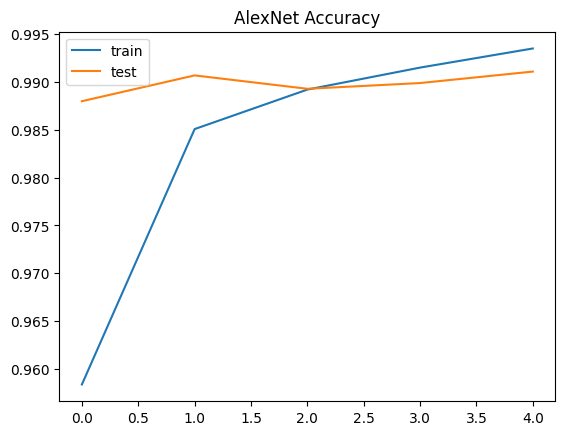

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

x_train = x_train.reshape(-1,28,28,1)/255.0
x_test = x_test.reshape(-1,28,28,1)/255.0

# Smaller AlexNet
model = models.Sequential([

    layers.Input(shape=(28,28,1)),

    layers.Conv2D(32,(3,3),activation='relu',padding='same'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64,(3,3),activation='relu',padding='same'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128,(3,3),activation='relu',padding='same'),

    layers.Flatten(),

    layers.Dense(256,activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(10,activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(x_train,y_train,epochs=5,validation_data=(x_test,y_test))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("AlexNet Accuracy")
plt.legend(['train','test'])
plt.show()